# Adım 1 Tek Nöron Forward Pass

**Görevin Amacı:**

- Bu adımda, numpy veya PyTorch gibi herhangi bir harici kütüphane kullanmaksızın, tamamen saf Python veri yapıları (list, float) ve temel döngüler aracılığıyla yapay bir nöronun ileriye doğru hesaplama (Forward Pass) mekanizmasını sıfırdan kodluyoruz.

Amacımız, bir derin öğrenme framework'ünün arka planında gerçekleşen temel matematiksel operasyonları doğrudan Python mantığıyla simüle etmektir.

### Yapay Nöron Biyolojik İlham ve Matematiksel Modelleme

Biyolojik sinir hücrelerinin veriyi işleme biçiminden esinlenilerek geliştirilen Yapay Nöron (Perceptron); birden fazla girdiyi alan, bu girdileri öğrenilebilir parametrelerle işleyen ve bünyesindeki aktivasyon mekanizması aracılığıyla tek bir çıktı üreten temel matematiksel bir fonksiyondur.

Matematiksel tanımı şu şekildedir:

$$y = f\left( \sum_{i=1}^{n} (x_i \cdot w_i) + b \right)$$

---

#### 1. Model Parametreleri ve Girdi Yapısı

Bir nöronun karar mekanizmasını oluşturan üç temel unsur vardır:

* **Girdi Vektörü ($\mathbf{x}$):** Sisteme beslenen ham veri özellikleridir ($x_1, x_2, \dots, x_n$). Örneğin bir gayrimenkul fiyatlama modelinde oda sayısı, metrekare veya bina yaşı birer girdi değişkenidir.
* **Ağırlık Vektörü ($\mathbf{w}$):** Her bir girdinin nihai tahmin üzerindeki bağıl etkisini (önem derecesini) kodlayan öğrenilebilir parametrelerdir ($w_1, w_2, \dots, w_n$). Değişkenin önemi arttıkça ilgili ağırlığın mutlak değeri büyür.
* **Sapma Değeri (Bias - $b$):** Tüm girdilerin sıfır olması durumunda dahi nöronun çıktı üretme esnekliğini düzenleyen sabittir. Doğru denklemindeki sabit terim ($y = mx + n$ yapısındaki $n$) ile aynı işlevi görür.

---

### Yapay Nöron Biyolojik İlham ve Matematiksel Modelleme

Biyolojik sinir hücrelerinin veriyi işleme biçiminden esinlenilerek geliştirilen Yapay Nöron (Perceptron); birden fazla girdiyi alan, bu girdileri öğrenilebilir parametrelerle işleyen ve bünyesindeki aktivasyon mekanizması aracılığıyla tek bir çıktı üreten temel matematiksel bir fonksiyondur.

**Nöronun genel işlem denklemi şu şekildedir:**

$$y = f\left( \sum_{i=1}^{n} (x_i \cdot w_i) + b \right)$$

Yukarıdaki genel eşitlikte görülen girdi, ağırlık ve sapma bileşenlerinin işlenme sürecini (**Forward Pass**) iki temel alt aşamada inceleyebiliriz:

---

#### 1. İleriye Doğru Hesaplama Süreci (Forward Pass)

Forward Pass, girdi verisinin model boyunca işlenerek adım adım nihai tahmine ($y$) dönüştürülmesi sürecidir. Yukarıdaki genel denklem şu iki ardışık adımın bileşkesinden oluşur:

* **Aşama A: Doğrusal Bileşke / Ağırlıklı Toplam ($z$):**  
  Genel denklemdeki parantez içi ifadedir. Girdi vektörü ile ağırlık vektörünün iç çarpımı (*dot product*) alınır ve sapma değeri eklenerek nöronun net doğrusal toplamı ($z$) elde edilir:

  $$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^{n} (x_i \cdot w_i) + b$$

     * **Vektörel Çarpım Notasyonu ($\mathbf{w}^T \mathbf{x}$):**
  $n \times 1$ boyutundaki ağırlık sütun vektörünün transpozu ($\mathbf{w}^T$) alınarak $1 \times n$ satır vektörüne dönüştürülür. Girdi vektörü ($\mathbf{x}$) ile iç çarpımı (*dot product*), her bir girdinin kendi ağırlığıyla çarpılıp toplanmasını ifade eder:
  $$\mathbf{w}^T \mathbf{x} = \sum_{i=1}^{n} (x_i \cdot w_i) = (x_1 w_1 + x_2 w_2 + \dots + x_n w_n)$$

* **Aşama B: Doğrusal Olmayan Dönüşüm / Aktivasyon ($y$):**  
  Aşama A'da hesaplanan $z$ değerinin, dıştaki $f(\cdot)$ süzgecinden geçirilerek nihai çıktıya dönüştürüldüğü kısımdır. Sadece doğrusal toplamların ($z$) üst üste eklenmesi, ağı kaç katmanlı olursa olsun tek bir doğrusal fonksiyona indirger. Modelin karmaşık ve doğrusal olmayan kalıpları öğrenebilmesi için $z$ değeri aktivasyon fonksiyonundan geçirilir:

  $$y = f(z)$$
#### 3. Aktivasyon Mekanizması: ReLU (Rectified Linear Unit)

Derin öğrenme literatüründe yaygın olarak tercih edilen aktivasyon fonksiyonlarından biri ReLU'dur. Fonksiyonun temel görevi, doğrusal bileşke sonucu elde edilen $z$ değerine göre nöronun uyarılma (ateşlenme) durumunu belirlemektir.

Matematiksel tanımı:

$$\text{ReLU}(z) = \max(0, z)$$

* $z \le 0$ durumu: Nöron pasifleşir (ateşlenmez) ve dışarıya $0$ çıktısı sunar.
* $z > 0$ durumu: Nöron aktifleşir ve giren değeri ölçeklemeden doğrudan dışarı aktarır.

#### Akışın Bütünsel Özeti

```plaintext
Girdiler (x) ve Ağırlıklar (w)
         │
         ▼
[ İç Çarpım: ∑(x_i * w_i) ] ──► [ Bias Ekleme: + b ] ──► (z: Doğrusal Toplam)
                                                                 │
                                                                 ▼
[ Çıktı: y ] ◄── [ Aktivasyon Fonksiyonu: ReLU(z) ] ◄────────────┘

In [11]:
# --- Adım 1: Saf Python ile Tek Nöron Forward Pass ---

# 1. Aktivasyon Fonksiyonu (ReLU)
def relu(z):
    return z if z > 0 else 0

# 2. Forward Pass Fonksiyonu
def single_neuron_forward(inputs, weights, bias):
    # 1. PARÇA: \sum_{i} (x_i \cdot w_i)  -->  Girdiler ile Ağırlıkların Çarpılıp Toplanması
    weighted_sum = sum(x * w for x, w in zip(inputs, weights))

    # 2. PARÇA: + b  -->  Ağırlıklı Toplama Bias Eklenmesi (z Değeri)
    z = weighted_sum + bias

    # 3. PARÇA: f(z)  -->  Aktivasyon Fonksiyonundan (ReLU) Geçirilerek Çıktının (y) Üretilmesi
    return relu(z)

# --- Test ---
inputs = [2.0, 3.0, -1.0]     # Girdiler (x)
weights = [0.5, -0.6, 0.8]    # Ağırlıklar (w)
bias = 1.2                    # Sapma (b)

# Çalıştır
output = single_neuron_forward(inputs, weights, bias)
print(f"Tek Nöron Çıktısı: {output}")

Tek Nöron Çıktısı: 0


Tam olarak öyle! Kodun çalışıp $0$ çıktısı vermesi, formülün kod tarafındaki birebir karşılığını doğruluyor:

* **Ağırlıklı Toplam:** $\sum (x_i \cdot w_i) = (2.0 \cdot 0.5) + (3.0 \cdot -0.6) + (-1.0 \cdot 0.8) = 1.0 - 1.8 - 0.8 = -1.6$
* **Bias Ekleme ($z$):** $z = -1.6 + 1.2 = -0.4$
* **Aktivasyon ($y = f(z)$):** $\text{ReLU}(-0.4) = \max(0, -0.4) = \mathbf{0}$

Elde edilen $0$ değeri, $z = -0.4 \le 0$ olduğu için nöronun pasif kaldığını (ateşlenmediğini) gösterir.

# Adım 2: Birden Fazla Nörondan Oluşan Katman Mimari Yapısı (Layer Forward Pass)

**Görevin Amacı:**

Tek bir nöronun işlem mantığını genişleterek, aynı girdi vektörünü eş zamanlı işleyen birden fazla nörondan müteşekkil tek bir Yapay Sinir Ağı Katmanı (Layer) oluşturmaktır. **Amacımız, tekil fonksiyon yapısını matrisel/vektörel düzeyde ifade etmek ve bir katmanın ileriye doğru hesaplama (Forward Pass) mekanizmasını kütüphane kullanmadan simüle etmektir.**

#### Bütünsel Bağlam ve Literatür Açıklaması
Adım 1'de tek bir nöronun girdi vektörünü ağırlıklandırarak skalar bir çıktı ürettiğini gördük. **Gerçek dünya problemlerinde ve derin öğrenme mimarilerinde tek bir nöron, verideki karmaşık özellikleri (*features*) temsil etmekte yetersiz kalır. Bu nedenle nöronlar katmanlar (*layers*) halinde paralel yapıda bir araya getirilir.**

Bir katmanda yer alan tüm nöronlar, aynı girdi vektörünü ($\mathbf{x}$) alırlar; ancak her bir nöronun kendisine ait bağımsız ağırlık vektörleri ve sapma (*bias*) değerleri vardır. Böylece katmandaki her nöron, girdi verisinin farklı bir özelliğini tespit etmeyi öğrenir.

#### Matematiksel Notasyon ve Katman İfadesi
$n$ adet girdiye ($x_1, x_2, \dots, x_n$) ve $m$ adet nörona sahip bir katmanı ele alalım:

* **Girdi Vektörü ($\mathbf{x}$):** $n \times 1$ boyutunda bir vektör:
$$\mathbf{x} = \begin{bmatrix} x_1 & x_2 & \dots & x_n \end{bmatrix}^T$$

* **Ağırlık Matrisi ($\mathbf{W}$):** Katmandaki $m$ adet nöronun ağırlıklarını içeren $m \times n$ boyutunda bir matris:
$$\mathbf{W} = \begin{bmatrix} w_{11} & w_{12} & \dots & w_{1n} \\ w_{21} & w_{22} & \dots & w_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m1} & w_{m2} & \dots & w_{mn} \end{bmatrix}$$
*(Burada $w_{ji}$, $j$. nöronun $i$. girdiye verdiği ağırlıktır.)*

* **Sapma Vektörü ($\mathbf{b}$):** Her nöronun sapmasını içeren $m \times 1$ boyutunda bir vektör:
$$\mathbf{b} = \begin{bmatrix} b_1 & b_2 & \dots & b_m \end{bmatrix}^T$$

#### İleriye Doğru Katman Hesaplaması (Layer Forward Pass)
Katmandaki doğrusal toplam vektörü ($\mathbf{z}$), ağırlık matrisi ile girdi vektörünün çarpımına sapma vektörünün eklenmesiyle elde edilir:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

**Boyut Analizi (Matris Çarpım Uyumu):**

$$\begin{bmatrix} z_1 \\ z_2 \\ \vdots \\ z_m \end{bmatrix}_{(m \times 1)} = \begin{bmatrix} w_{11} & w_{12} & \dots & w_{1n} \\ w_{21} & w_{22} & \dots & w_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m1} & w_{m2} & \dots & w_{mn} \end{bmatrix}_{(m \times n)} \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}_{(n \times 1)} + \begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_m \end{bmatrix}_{(m \times 1)}$$

$(m \times n) \cdot (n \times 1) = (m \times 1)$ boyutunda bir vektör üretir.


Üretilen bu vektöre $(m \times 1)$ boyutundaki $\mathbf{b}$ eklenince, her nöronun doğrusal toplamı ($z_j$) tek bir sütun vektöründe toplanmış olur.

Nihai katman çıktı vektörü ($\mathbf{a}$ veya $\mathbf{y}$), doğrusal toplamın eleman bazlı (*element-wise*) aktivasyon fonksiyonundan ($f$) geçirilmesiyle üretilir:

$$\mathbf{a} = f(\mathbf{z}) = f(\mathbf{W}\mathbf{x} + \mathbf{b})$$

#### Akışın Bütünsel Özeti

```plaintext
               Girdi Vektörü (x) [ Boyut: n x 1 ]
                              │
                              ▼
   [ Ağırlık Matrisi (W) x Girdi Vektörü (x) ]  ──►  Boyut: m x 1
                              │
                              ▼
          [ + Sapma Vektörü (b) ]               ──►  z Vektörü (m x 1)
                              │
                              ▼
   [ Eleman Bazlı Aktivasyon: f(z) ]            ──►  a Çıktı Vektörü (m x 1)

In [12]:
# --- Adım 2: Saf Python ile Katman (Layer) Forward Pass ---

# 1. Aktivasyon Fonksiyonu (ReLU)
def relu(z):
    return z if z > 0 else 0

# 2. Tek Nöron Forward Pass (Adım 1'den)
def single_neuron_forward(inputs, weights, bias):
    weighted_sum = sum(x * w for x, w in zip(inputs, weights))
    z = weighted_sum + bias
    return relu(z)

# 3. Katman Forward Pass Fonksiyonu
def layer_forward(inputs, weights_matrix, biases):
    layer_outputs = []

    # Katmandaki her bir nöron için sırayla forward pass çalıştırılır
    for weights, bias in zip(weights_matrix, biases):
        neuron_output = single_neuron_forward(inputs, weights, bias)
        layer_outputs.append(neuron_output)

    return layer_outputs

# --- Test ---
# Girdi Vektörü (x) -> 3 elemanlı (n=3)
x = [2.0, 3.0, -1.0]

# Ağırlık Matrisi (W) -> 2 nöron (m=2), her birinin 3 ağırlığı var (2x3 boyutlu)
W = [
    [0.5, -0.6, 0.8],  # 1. Nöronun ağırlık vektörü (w_1)
    [0.1,  0.4, 0.9]   # 2. Nöronun ağırlık vektörü (w_2)
]

# Sapma Vektörü (b) -> 2 nöron için 2 sapma değeri (m=2)
b = [1.2, -0.5]

# Katман Çıktısını Hesapla
output_vector = layer_forward(x, W, b)
print(f"Katman Çıktı Vektörü (a): {output_vector}")

Katman Çıktı Vektörü (a): [0, 2.220446049250313e-16]


Elde edilen $\mathbf{a} = [0, 2.22 \times 10^{-16}]$ çıktı vektörünün matematiksel ve sistemsel karşılığı şudur:

1. **1. Nöron ($a_1 = 0$):**  
   Doğrusal toplam $z_1 = -1.6 + 1.2 = -0.4$ olarak hesaplanmıştır. Değer negatif olduğu için ReLU aktivasyonu fonksiyonu nöronu pasifleştirmiş ve tam olarak $0$ çıktısı ürettirmiştir.

2. **2. Nöron ($a_2 = 2.22 \times 10^{-16} \approx 0$):**  
   Doğrusal toplam $z_2 = (2.0 \cdot 0.1) + (3.0 \cdot 0.4) + (-1.0 \cdot 0.9) - 0.5 = 0.0$ olarak hesaplanmıştır. Matematiksel olarak teorik sonuç $0$'dır. Çıktıdaki $2.22 \times 10^{-16}$ değeri, bilgisayarların ondalıklı sayıları (*floating-point*) işlerken yaşadığı minik bir duyarlılık/hassasiyet sapmasıdır ve pratikte $0$ demektir.

# Adım 3: Basit Bir Loss Fonksiyonu (MSE - Mean Squared Error)

**Görevin Amacı:**
Modelimizin (nöron veya katman) ürettiği tahmin çıktısı ($\hat{y}$) ile ulaşmak istediğimiz gerçek hedef değer ($y$) arasındaki farkı, yani modelin hata miktarını (Loss / Cost) matematiksel olarak tek bir skalar sayı ile ifade etmektir.

#### **Bütünsel Bağlam ve Literatür Açıklaması**
Adım 1 ve Adım 2'de verinin model içerisinde soldan sağa akışını (Forward Pass) kodladık. Ancak rasgele veya elle belirlenmiş ağırlıklarla çalışan bir modelin ne kadar "doğru" ya da "hatalı" tahmin yaptığını ölçmeden modeli eğitemeyiz.

Loss (Kayıp/Hata) Fonksiyonu, modelin tahminleri ile gerçek hedefler arasındaki sapmayı nitelendiren bir fonksiyondur. Derin öğrenmede amacımız bu loss değerini minimuma indirmektir.

#### **Matematiksel Notasyon: Ortalama Kare Hata (MSE)**
Regresyon ve temel öğrenme problemlerinde sıklıkla kullanılan en temel kayıp fonksiyonu Mean Squared Error (MSE)'dir.

$N$ adet veri örneği için matematiksel tanımı:

$$L = \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

* **$\hat{y}_i$ (`y_pred`):** Modelin $i$. örnek için ürettiği tahmin değeri.
* **$y_i$ (`y_true`):** Veri kümesinde olması gereken gerçek hedef (*target*) değer.
* **$(\hat{y}_i - y_i)^2$:** Hatanın karesi. Kare alma işlemi iki temel amaca hizmet eder:
  1. Pozitif ve negatif hataların birbirini götürmesini engeller (hatayı her zaman pozitif yapar).
  2. Büyük hataları daha ağır cezalandırır.
* **$\frac{1}{N} \sum$:** Tüm örnekler üzerinden hataların ortalamasını alır.

In [13]:
# --- Adım 3: Saf Python ile MSE Loss Fonksiyonu ---

def mse_loss(y_pred, y_true):
    # Tekil sayısal değer verilirse listeye dönüştür
    if not isinstance(y_pred, list):
        y_pred = [y_pred]
    if not isinstance(y_true, list):
        y_true = [y_true]

    N = len(y_true)

    # Hataların kareleri toplamı: ∑ (y_pred_i - y_true_i)^2
    squared_errors_sum = sum((pred - true) ** 2 for pred, true in zip(y_pred, y_true))

    # Ortalama Kare Hata (MSE)
    loss = squared_errors_sum / N
    return loss

# --- Test ---
# Örneğin, modelimizin tahmini (y_pred) 0.82 olsun, gerçek hedef (y_true) ise 2.5 olsun.
y_pred = [0.82]
y_true = [2.5]

loss_val = mse_loss(y_pred, y_true)
print(f"Hesaplanan Loss (Hata) Değeri: {loss_val}")

Hesaplanan Loss (Hata) Değeri: 2.8224000000000005


Elde edilen $2.8224$ Loss değerinin matematiksel ve sistemsel karşılığı şudur:

**Matematiksel Hesaplama:**

$$\text{Hata (Error)} = \hat{y} - y = 0.82 - 2.5 = -1.68$$

$$\text{Kare Hata (Squared Error)} = (-1.68)^2 = \mathbf{2.8224}$$

**Sistemsel Anlamı:**

* **Mevcut Durum:** Modelimiz $2.5$ üretmesi gerekirken $0.82$ değerini üretmiş, yani hedefin gerisinde kalmıştır.
* **Metriğin Doğrulanması:** MSE fonksiyonu farkın karesini aldığı için pozitif bir ceza puanı ($2.8224$) üretmiştir.
* **Öğrenme Amacı:** Amacımız, sonraki adımlarda ağırlık ($w$) ve sapma ($b$) parametrelerini güncelleyerek bu $2.8224$ değerini mümkün olduğunca $0$'a yaklaştırmaktır.

# Adım 4: Parametre Değişimi ve Loss Eğrisinin Görselleştirilmesi (Loss Curve)

**Görevin Amacı:**

Model parametrelerinden birini ($w_3$) geniş bir aralıkta elle (manuel) değiştirerek (*nudge*), bu değişimin MSE Loss üzerindeki etkisini gözlemlemek ve parametre-loss ilişkisini temsil eden Loss Eğrisini (*Loss Curve / Optimization Landscape*) `matplotlib` kütüphanesi ile görselleştirmektir.

#### Bütünsel Bağlam ve Literatür Açıklaması
Adım 1 ve Adım 2'de ileriye doğru hesaplama (*Forward Pass*) ile çıktı üretmeyi, Adım 3'te ise üretilen çıktının kalitesini ölçen MSE Loss fonksiyonunu tanımladık.

3Blue1Brown ve Karpathy'nin de vurguladığı gibi, bir yapay sinir ağının öğrenme süreci aslında maliyet (*loss*) fonksiyonunun minimum noktasını arama işlemidir. Parametre alanındaki küçük değişimlerin ($w \to w + \Delta w$) hata üzerindeki yansımasını anlamak, türev ve Gradient Descent (Gradyan İnişi) sezgisini kazanmanın ilk adımıdır.

#### Matematiksel Notasyon ve Problem Kurgusu
Sabit bir girdi vektörü ($\mathbf{x}$) ve tek bir hedef ($y$) için nöronumuzun ileri yönlü hesaplaması ve kayıp fonksiyonu şu şekildedir:

$$\hat{y} = \text{ReLU}(x_1 w_1 + x_2 w_2 + x_3 w_3 + b)$$

$$L(w_3) = \text{MSE}(\hat{y}, y) = (\hat{y} - y)^2$$

Bu adımda $w_1, w_2$ ve $b$ değerlerini sabit tutarak, $L$ fonksiyonunu yalnızca $w_3$ ağırlığına bağlı tek değişkenli bir fonksiyon $L(w_3)$ olarak ele alıyoruz.

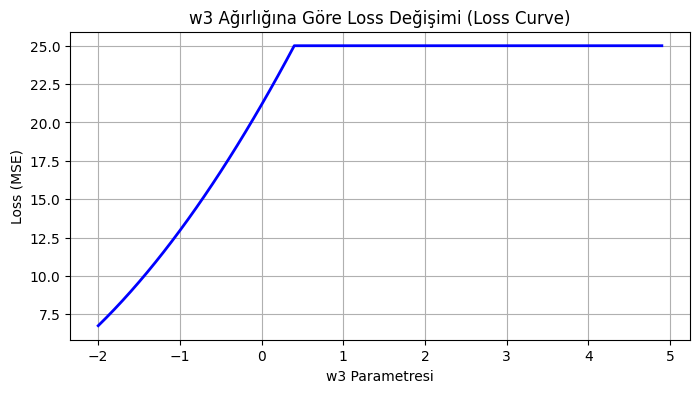

In [14]:
# --- Adım 4: Parametre Değişimi & Loss Eğrisi Çizimi ---
import matplotlib.pyplot as plt

# 1. Önceki Adımlardan Fonksiyon Tanımları
def relu(z):
    return z if z > 0 else 0

def single_neuron_forward(inputs, weights, bias):
    z = sum(x * w for x, w in zip(inputs, weights)) + bias
    return relu(z)

def mse_loss(y_pred, y_true):
    if not isinstance(y_pred, list): y_pred = [y_pred]
    if not isinstance(y_true, list): y_true = [y_true]
    return sum((pred - true) ** 2 for pred, true in zip(y_pred, y_true)) / len(y_true)

# 2. Sabit Girdi (x) ve Gerçek Hedef (y_true)
x_val = [2.0, 3.0, -1.0]
y_true = [5.0]

# 3. Sabit Parametreler
w_fixed = [0.5, -0.6]  # w1 ve w2 sabit
bias_fixed = 1.2       # bias sabit

# 4. w3 Parametresini Manuel Değiştirme Aralığı: [-2.0, 5.0]
w3_range = [i * 0.1 for i in range(-20, 50)]
losses = []

# 5. İteratif Forward Pass ve Loss Hesaplama
for w3 in w3_range:
    current_weights = [w_fixed[0], w_fixed[1], w3]

    # Forward Pass
    pred = single_neuron_forward(x_val, current_weights, bias_fixed)

    # Loss Hesaplama
    loss = mse_loss(pred, y_true)
    losses.append(loss)

# 6. Loss Eğrisini Çizdirme
plt.figure(figsize=(8, 4))
plt.plot(w3_range, losses, color='blue', linewidth=2)
plt.title("w3 Ağırlığına Göre Loss Değişimi (Loss Curve)")
plt.xlabel("w3 Parametresi")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

Oluşan grafik tam olarak beklemediğimiz ama ReLU aktivasyon fonksiyonunun doğası gereği ortaya çıkan çok kritik bir durumu gösteriyor.

Grafik iki farklı bölgeden oluşuyor. Bunları yalın bir dille analiz edelim:

**Grafik Analizi ve Yorumu**

**1. Yükselen Çizgi Bölgesi ($w_3 < 0.4$ aralığı)**  
* **Ne Oluyor?:** $w_3$ ağırlığı negatif yönde küçüldükçe hatanın (Loss) azaldığı görülür.
* **Neden?:** Çünkü girdi $x_3 = -1.0$ değerindedir. Negatif bir girdiyi negatif bir $w_3$ ağırlığıyla çarptığımızda sonuç pozitif olur. Böylece toplam $z$ değeri pozitifleşir, nöron ReLU süzgecinden geçer (ateşlenir) ve hedefimiz olan $5.0$ değerine yaklaşır. $w_3$ negatifleştikçe hedefimize yaklaştığımız için Loss düşer.

**2. Düz Çizgi Bölgesi ($w_3 \ge 0.4$ aralığı — "Dead ReLU")**  
* **Ne Oluyor?:** $w_3$ değeri $0.4$'ün üzerine çıktığında Loss $25.0$ değerinde sabit kalır ve eğim sıfır ($0$) olur.
* **Neden?:** $x_3 = -1.0$ iken pozitif bir $w_3$ seçilirse çarpım negatif olur. Bu durum nöronun toplam $z$ değerini sıfır veya negatif yapar. ReLU sıfırın altındaki her şeyi $0$ çıktısına eşitlediği için nöron tamamen kapanır ($\hat{y} = 0$).

**Hata Hesabı:**  
Çıktı $0$, hedef $5.0$ olduğunda MSE hatası:

$$\text{Loss} = (0 - 5.0)^2 = 25.0$$

Nöron kapalı kaldığı sürece $w_3$'ü ne kadar büyütürsek büyütelim çıktı $0$, hata ise $25.0$ olarak sabitleşir.


> Bu grafik, yapay zekada **"Dead ReLU" (Ölü ReLU)** olarak bilinen olguyu net bir şekilde özetler: Nöron pasifleştiğinde ($0$ ürettiğinde), parametre değişse bile çıktı ve hata değişmez.


# Adım 5: Sayısal Türev (Numerical Derivative) ve Gradient Descent Döngüsü

**Görevin Amacı:**
Karpathy'nin ve 3Blue1Brown'un anlatımındaki temel yaklaşımı uygulayarak, sayısal türev (numerical derivative) yöntemiyle loss fonksiyonunun parametrelere göre eğimini (grad) hesaplamak ve bu eğim doğrultusunda parametreleri güncelleyerek loss değerini adım adım düşüren bir Gradient Descent (Gradyan İnişi) döngüsü kurmaktır.  

#### Bütünsel Bağlam ve Matematiksel Notasyon
Adım 4'te parametrelerin manuel değişiminin loss üzerindeki etkisini inceledik. Ancak binlerce parametresi olan bir ağda manuel değişim imkansızdır. Modelin kendi kendine öğrenmesi, türev (eğim) bilgisiyle mümkündür.  

#### 1. Sayısal Türev (Numerical Derivative)
Calculus'taki türev tanımına göre bir $f(x)$ fonksiyonunun $x$ noktasındaki eğimi, $h \to 0$ iken limit değeridir:  

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

Bilgisayar ortamında çok küçük bir $h$ adım miktarı ($h = 0.0001$) seçerek herhangi bir parametrenin loss üzerindeki sayısal türevini (grad) yaklaşık olarak hesaplayabiliriz:  

$$\text{grad} = \frac{\text{Loss}(w + h) - \text{Loss}(w)}{h}$$

#### 2. Gradient Descent Güncelleme Kuralı
Türev (grad), fonksiyonun artış yönünü gösterir. Loss değerini azaltmak istediğimiz için parametreleri gradyanın tersi yönünde güncelleriz:  

$$w_{\text{yeni}} = w_{\text{eski}} - (\text{learning\_rate} \times \text{grad})$$

**Learning Rate ($\eta$):** Her adımda ne kadarlık bir güncelleme yapılacağını belirleyen adım boyutudur.

In [15]:
# --- Adım 5: Sayısal Türev ve Gradient Descent Döngüsü ---

# 1. Temel Yapılar (Önceki Adımlardan)
def relu(z):
    return z if z > 0 else 0

def single_neuron_forward(inputs, weights, bias):
    z = sum(x * w for x, w in zip(inputs, weights)) + bias
    return relu(z)

def mse_loss(y_pred, y_true):
    if not isinstance(y_pred, list): y_pred = [y_pred]
    if not isinstance(y_true, list): y_true = [y_true]
    return sum((pred - true) ** 2 for pred, true in zip(y_pred, y_true)) / len(y_true)

# 2. Veri ve Başlangıç Parametreleri
inputs = [2.0, 3.0, -1.0]
y_true = [5.0]

weights = [0.5, -0.6, 0.1]  # Başlangıç ağırlıkları
bias = 1.2                  # Başlangıç sapması

learning_rate = 0.01        # Adım boyutu (eta)
h = 0.0001                  # Sayısal türev adım miktarı
epochs = 20                 # Eğitim adım sayısı

print(f"Başlangıç Ağırlıkları: {weights}, Bias: {bias}")
initial_pred = single_neuron_forward(inputs, weights, bias)
print(f"Başlangıç Tahmini: {initial_pred:.4f}, Başlangıç Loss: {mse_loss(initial_pred, y_true):.4f}\n")

# 3. Gradient Descent Eğitimi Döngüsü
for epoch in range(epochs):
    # A. Mevcut durumun forward pass ve loss hesaplaması
    current_pred = single_neuron_forward(inputs, weights, bias)
    current_loss = mse_loss(current_pred, y_true)

    # B. Ağırlıklar için Sayısal Türev Hesaplama
    weight_grads = []
    for i in range(len(weights)):
        # i. ağırlığı h kadar artırıp değişimi gözlemle
        weights_plus_h = list(weights)
        weights_plus_h[i] += h

        pred_plus_h = single_neuron_forward(inputs, weights_plus_h, bias)
        loss_plus_h = mse_loss(pred_plus_h, y_true)

        # dLoss / dw_i
        grad = (loss_plus_h - current_loss) / h
        weight_grads.append(grad)

    # C. Bias için Sayısal Türev Hesaplama (dLoss / db)
    bias_plus_h = bias + h
    pred_bias_plus_h = single_neuron_forward(inputs, weights, bias_plus_h)
    loss_bias_plus_h = mse_loss(pred_bias_plus_h, y_true)
    bias_grad = (loss_bias_plus_h - current_loss) / h

    # D. Parametreleri Güncelleme (Gradient Descent)
    for i in range(len(weights)):
        weights[i] -= learning_rate * weight_grads[i]
    bias -= learning_rate * bias_grad

    # Her 5 adımda bir durumu bas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {current_loss:.4f} | Tahmin: {current_pred:.4f}")

print("\n--- Eğitim Tamamlandı ---")
final_pred = single_neuron_forward(inputs, weights, bias)
print(f"Son Tahmin: {final_pred:.4f} (Hedef: {y_true[0]})")
print(f"Son Loss Değeri: {mse_loss(final_pred, y_true):.4f}")
print(f"Güncellenmiş Ağırlıklar: {[round(w, 4) for w in weights]}")
print(f"Güncellenmiş Bias: {round(bias, 4)}")

Başlangıç Ağırlıkları: [0.5, -0.6, 0.1], Bias: 1.2
Başlangıç Tahmini: 0.3000, Başlangıç Loss: 22.0900

Epoch  1 | Loss: 22.0900 | Tahmin: 0.3000
Epoch  5 | Loss: 1.2736 | Tahmin: 3.8714
Epoch 10 | Loss: 0.0360 | Tahmin: 4.8102
Epoch 15 | Loss: 0.0010 | Tahmin: 4.9680
Epoch 20 | Loss: 0.0000 | Tahmin: 4.9945

--- Eğitim Tamamlandı ---
Son Tahmin: 4.9961 (Hedef: 5.0)
Son Loss Değeri: 0.0000
Güncellenmiş Ağırlıklar: [1.1262, 0.3392, -0.2131]
Güncellenmiş Bias: 1.5131


**Çıktı Analizi ve Yorumu**

**Hatanın Düşüşü (Loss Convergence)**:
- Eğitimin başlangıcında $22.0900$ olan MSE Loss değeri, 20 adım (epoch) sonunda $0.0000$ seviyesine gerilemiştir. Modelin öğrenme eğrisi kararlı bir şekilde yakınsamıştır (*converge*).

**Tahmin Başarısı:**
- Nöronun başlangıçtaki tahmini $0.3000$ iken, Gradient Descent algoritması sayesinde hedef değer olan $5.0$ seviyesine yaklaşarak $4.9961$ değerine ulaşmıştır.

**Parametre Güncellemesi (Learning):**
- Sayısal türev ile hesaplanan gradyanlar doğrultusunda parametreler optimize edilmiştir:
   * **Ağırlıklar ($W$):** $[0.5, -0.6, 0.1]$ değerinden $[1.1262, 0.3392, -0.2131]$ değerine güncellenmiştir.
   * **Sapma ($b$):** $1.2$ değerinden $1.5131$ değerine yükselmiştir.



> Model, sayısal türev alarak hangi parametreyi ne kadar değiştirmesi gerektiğini matematiksel olarak bulmuş ve hedef çıktıya minimum hatayla ulaşmayı başarmıştır.

